# M. Royhan Firdaus Asy Syifa

# Optimizing Random Forest and Gradient Boosting for Bank Marketing Insights

| **Feature**   | **Description**                                                       |
| ------------- | --------------------------------------------------------------------- |
| **age**       | Age of the client.                                                    |
| **job**       | Type of job the client has.                                           |
| **marital**   | Marital status of the client.                                         |
| **education** | Client’s education level.                                             |
| **default**   | Whether the client has credit in default.                             |
| **housing**   | Whether the client has a housing loan.                                |
| **loan**      | Whether the client has a personal loan.                               |
| **contact**   | Type of communication used for contact.                               |
| **month**     | Last contact month of the year.                                       |
| **day**       | Last contact day of the week.                                         |
| **duration**  | Duration of the last contact in seconds.                              |
| **campaign**  | Number of contacts performed during this campaign.                    |
| **pdays**     | Days since last contact in previous campaign (999 = never contacted). |
| **previous**  | Number of contacts before this campaign.                              |
| **poutcome**  | Outcome of the previous marketing campaign.                           |
| **y**         | Whether the client subscribed to a term deposit.                      |


In [ ]:
# import library
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import tree

In [ ]:
# load dataset
pd.set_option('display.max_columns', None) # Display all columns

url = "https://raw.githubusercontent.com/NathaliaMinoque/datasets/refs/heads/main/Bank%20(1).csv"
df = pd.read_csv(url, sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
# get info from dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [ ]:
# get statistical info from dataset
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


# Preprocessing

In [ ]:
# show unique values from dataset
unique_values = {col: df[col].unique() for col in df.columns}
display(unique_values)

{'age': array([30, 33, 35, 59, 36, 39, 41, 43, 20, 31, 40, 56, 37, 25, 38, 42, 44,
        26, 55, 67, 53, 68, 32, 49, 78, 23, 52, 34, 61, 45, 48, 57, 54, 63,
        51, 29, 50, 27, 60, 28, 21, 58, 22, 46, 24, 77, 75, 47, 70, 65, 64,
        62, 66, 19, 81, 83, 80, 71, 72, 69, 79, 73, 86, 74, 76, 87, 84]),
 'job': array(['unemployed', 'services', 'management', 'blue-collar',
        'self-employed', 'technician', 'entrepreneur', 'admin.', 'student',
        'housemaid', 'retired', 'unknown'], dtype=object),
 'marital': array(['married', 'single', 'divorced'], dtype=object),
 'education': array(['primary', 'secondary', 'tertiary', 'unknown'], dtype=object),
 'default': array(['no', 'yes'], dtype=object),
 'balance': array([ 1787,  4789,  1350, ...,  -333, -3313,  1137]),
 'housing': array(['no', 'yes'], dtype=object),
 'loan': array(['no', 'yes'], dtype=object),
 'contact': array(['cellular', 'unknown', 'telephone'], dtype=object),
 'day': array([19, 11, 16,  3,  5, 23, 14,  6, 17, 20,

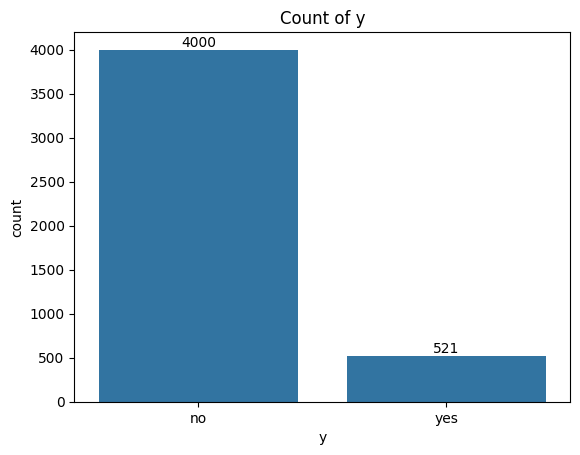

In [ ]:
# show how many attrition
ax = sns.countplot(data=df, x='y')
plt.title('Count of y')

# Add labels to the bars
for container in ax.containers:
    ax.bar_label(container)
plt.show()

# imbalance dataset but it's okay let us try firsttt

# Insightful Visualization

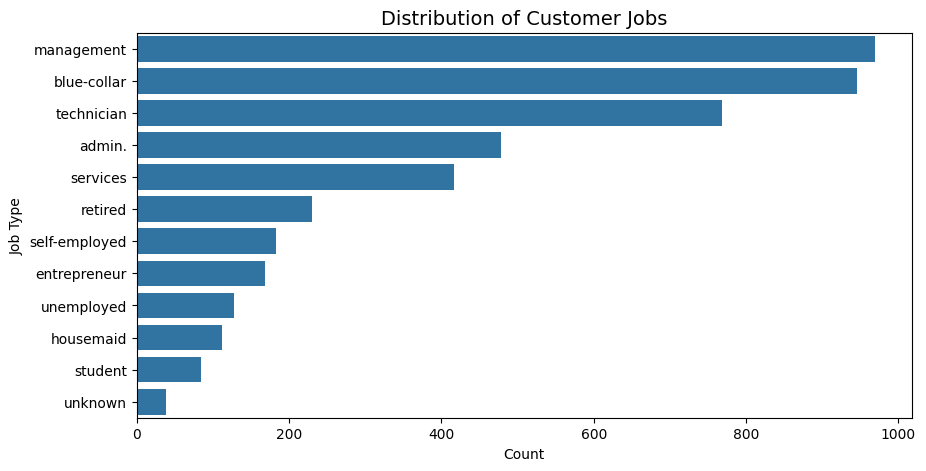

In [ ]:
# 1. job proportion
plt.figure(figsize=(10,5))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title("Distribution of Customer Jobs", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Job Type")
plt.show()

The chart shows that most customers work in management and blue-collar jobs, followed by technicians and administrative workers. Jobs like students, housemaids, and unknown have the fewest customers. This means the bank’s customers mostly come from formal working sectors, suggesting that banking products are more popular among professionals and employed individuals.

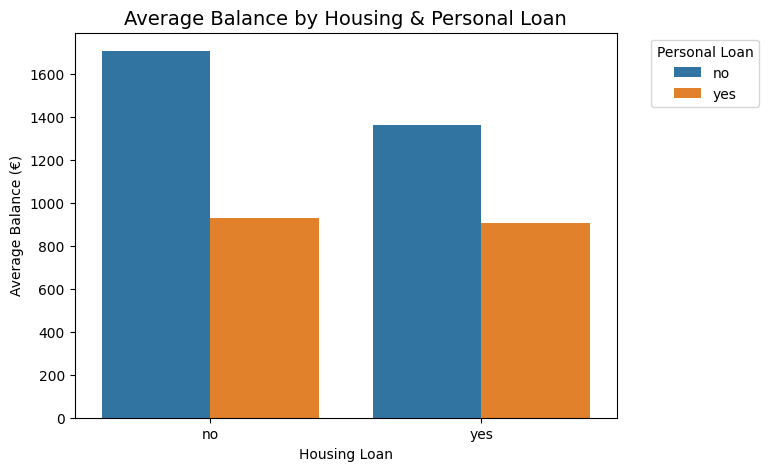

In [ ]:
# 2.  the average balance based on housing and personal loans
avg_balance = df.groupby(['housing', 'loan'])['balance'].mean().reset_index()

plt.figure(figsize=(7,5))
sns.barplot(data=avg_balance, x='housing', y='balance', hue='loan')
plt.title("Average Balance by Housing & Personal Loan", fontsize=14)
plt.xlabel("Housing Loan")
plt.ylabel("Average Balance (€)")
plt.legend(title="Personal Loan", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

The chart shows the average balance based on housing and personal loans. Customers without any personal or housing loans tend to have the highest average balance. Meanwhile, those who have both types of loans usually keep lower balances. This suggests that loan commitments may reduce the amount of money customers keep in their accounts.

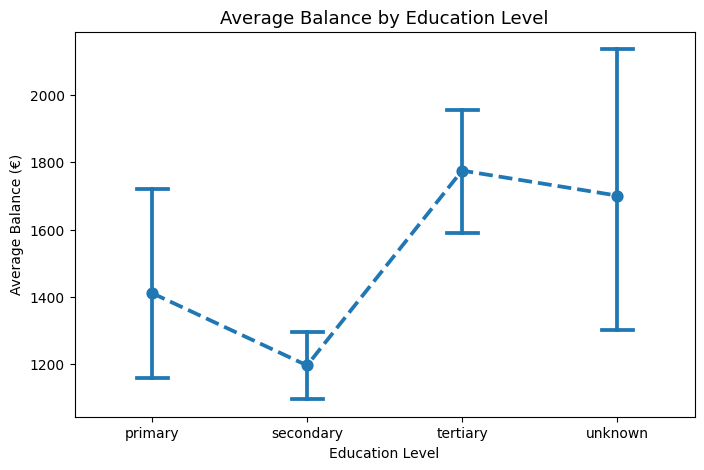

In [ ]:
# the average balance for each education level.
plt.figure(figsize=(8,5))
sns.pointplot(data=df, x='education', y='balance', color='#1f77b4', markers='o', linestyles='--', capsize=0.2)
plt.title("Average Balance by Education Level", fontsize=13)
plt.xlabel("Education Level")
plt.ylabel("Average Balance (€)")
plt.show()


The chart shows the average balance for each education level. Customers with tertiary education tend to have the highest average balance, while those with secondary education have the lowest. This suggests that higher education levels may be linked to better financial stability or higher income.

# Feature Encoding

the encoding process is used to change data from strings into numbers

As you can see, we will change some of the column contents, such as the y, default, housing, and loan columns. I will change them to 0 for no and 1 for yes because these columns are binary data types.

we also changed nominal data such as contact, job, marital status, and outcome.

Furthermore, we mapped ordinal data, namely month and education.

In [ ]:
# duplicate df
df_encoded = df.copy()

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

# 1. One-Hot Encoding
# Columns: Attrition, Gender, OverTime

one_hot_map = {
    'y': {'no': 0, 'yes': 1},
    'default': {'no': 0, 'yes': 1},
    'housing': {'no': 0, 'yes': 1},
    'loan': {'no': 0, 'yes': 1},
}

for col, mapping in one_hot_map.items():
    df_encoded[col] = df_encoded[col].map(mapping)


# 2. Nominal Encoding
# Suppose you already fitted the encoder:
nominal_cols = ['contact', 'job', 'marital','poutcome']
encoder = OrdinalEncoder()
df_encoded[nominal_cols] = encoder.fit_transform(df_encoded[nominal_cols])

# 3. Ordinal Encoding
Month_mapping = {
    'jan': 0,
    'feb': 1,
    'mar': 2,
    'apr': 3,
    'may': 4,
    'jun': 5,
    'jul': 6,
    'aug': 7,
    'sep': 8,
    'oct': 9,
    'nov': 10,
    'dec': 11
}
df_encoded['month'] = df_encoded['month'].map(Month_mapping)

Education_mapping = {
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}

df_encoded['education'] = df_encoded['education'].map(Education_mapping)


# Build a mapping dictionary
encode_dict = {}

for col, cats in zip(nominal_cols, encoder.categories_):
    encode_dict[col] = {category: int(code) for code, category in enumerate(cats)}

# Show the full dictionary
import pprint
pprint.pprint(encode_dict)

df_encoded.sample(n = 5)

{'contact': {'cellular': 0, 'telephone': 1, 'unknown': 2},
 'job': {'admin.': 0,
         'blue-collar': 1,
         'entrepreneur': 2,
         'housemaid': 3,
         'management': 4,
         'retired': 5,
         'self-employed': 6,
         'services': 7,
         'student': 8,
         'technician': 9,
         'unemployed': 10,
         'unknown': 11},
 'marital': {'divorced': 0, 'married': 1, 'single': 2},
 'poutcome': {'failure': 0, 'other': 1, 'success': 2, 'unknown': 3}}


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
1968,52,4.0,1.0,3,0,0,1,0,0.0,9,6,197,1,-1,0,3.0,0
3930,51,5.0,0.0,2,0,1679,0,0,0.0,12,7,417,1,365,9,1.0,1
2552,23,7.0,1.0,2,0,-19,1,0,2.0,20,5,13,10,-1,0,3.0,0
125,34,6.0,2.0,3,0,462,0,0,0.0,21,7,1877,3,-1,0,3.0,1
815,32,1.0,1.0,2,0,456,0,0,0.0,12,4,121,1,-1,0,3.0,0


In [ ]:
# checking encode result
df.loc[3246]

,3246
age,33
job,blue-collar
marital,married
education,secondary
default,no
balance,-241
housing,yes
loan,yes
contact,unknown
day,27


## Separate features and target

### Subtask:
Define the features (X) and the target variable (y).


**Reasoning**:
Define the features (X) by dropping the target variable 'Attrition' from the DataFrame and define the target variable (y) as the 'Attrition' column.



In [ ]:
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

In [ ]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,30,10.0,1.0,1,0,1787,0,0,0.0,19,9,79,1,-1,0,3.0
1,33,7.0,1.0,2,0,4789,1,1,0.0,11,4,220,1,339,4,0.0
2,35,4.0,2.0,3,0,1350,1,0,0.0,16,3,185,1,330,1,0.0
3,30,4.0,1.0,3,0,1476,1,1,2.0,3,5,199,4,-1,0,3.0
4,59,1.0,1.0,2,0,0,1,0,2.0,5,4,226,1,-1,0,3.0


In [ ]:
y.head()

,y
0,0
1,0
2,0
3,0
4,0


## Split data

### Subtask:
Split the encoded data into training and testing sets.


**Reasoning**:



Split the encoded feature DataFrame X and the target Series y into training and testing sets.



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
# check the shape of X_train and X_test

X_train.shape, X_test.shape

((3164, 16), (1357, 16))

In [ ]:
X_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
565,40,9.0,1.0,2,0,56,1,1,0.0,29,0,194,1,247,1,0.0
3480,47,7.0,1.0,2,0,440,1,0,2.0,12,5,91,1,-1,0,3.0
2125,52,9.0,1.0,2,0,3554,0,1,0.0,8,6,89,1,-1,0,3.0
3452,31,0.0,1.0,2,0,0,1,0,0.0,29,6,82,5,-1,0,3.0
1667,33,1.0,1.0,2,0,-346,1,1,2.0,23,4,29,3,-1,0,3.0


In [ ]:
X_test.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
4274,35,1.0,1.0,1,0,378,1,0,2.0,16,4,427,3,-1,0,3.0
72,31,4.0,2.0,3,0,6248,1,0,2.0,9,4,154,2,-1,0,3.0
1065,30,10.0,1.0,3,0,0,1,0,0.0,18,10,756,1,-1,0,3.0
3185,42,0.0,1.0,2,0,529,1,1,0.0,19,10,193,3,-1,0,3.0
130,41,1.0,1.0,1,0,168,1,0,0.0,18,10,187,3,-1,0,3.0


we just want to see how the performance using desicion tree before developmnet using oversampling data until using hyperparamter tuning

# Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2810
           1       1.00      1.00      1.00       354

    accuracy                           1.00      3164
   macro avg       1.00      1.00      1.00      3164
weighted avg       1.00      1.00      1.00      3164


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1190
           1       0.41      0.44      0.42       167

    accuracy                           0.85      1357
   macro avg       0.66      0.68      0.67      1357
weighted avg       0.86      0.85      0.85      1357



# Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2810
           1       1.00      1.00      1.00       354

    accuracy                           1.00      3164
   macro avg       1.00      1.00      1.00      3164
weighted avg       1.00      1.00      1.00      3164


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1190
           1       0.60      0.30      0.40       167

    accuracy                           0.89      1357
   macro avg       0.75      0.64      0.67      1357
weighted avg       0.87      0.89      0.87      1357



# GradientBoosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report

gbc = GradientBoostingClassifier(random_state=0)
gbc.fit(X_train, y_train)

y_pred_train = gbc.predict(X_train)
y_pred_test = gbc.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2810
           1       0.88      0.51      0.64       354

    accuracy                           0.94      3164
   macro avg       0.91      0.75      0.80      3164
weighted avg       0.93      0.94      0.93      3164


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1190
           1       0.58      0.33      0.42       167

    accuracy                           0.89      1357
   macro avg       0.75      0.65      0.68      1357
weighted avg       0.87      0.89      0.87      1357



as you can see, the f1 score for testing set is not balance even the accuracy is quite good for all model (Decisition Tre, Random Forest, GradienBoosting). so

# What to do next?
*   The F1 Score also significantly different so we need to handle this imbalance dataset. <br>
*   The accuracy of training set is 100% and testing set is 85%. This indicates overfitting, therefore we need to apply pre-prunning to the tree. We will tune the parameter by add a max_depth (limiting the depth/ branching of tree) and etc. <br>
*   And maybe we need to select and drop some features for the model.

# Oversampling using SMOTENC

In [ ]:
# using SMOTE-NC for dataset containing numerical and categorical features.

from imblearn.over_sampling import SMOTENC

# we should define the categorical features first to make oversampling more accurate
categorical_features = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'day',
    'poutcome'
]

smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

# dont forget to always do partitioning AFTER undersampling/oversampling
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=0)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((5600, 16), (2400, 16))

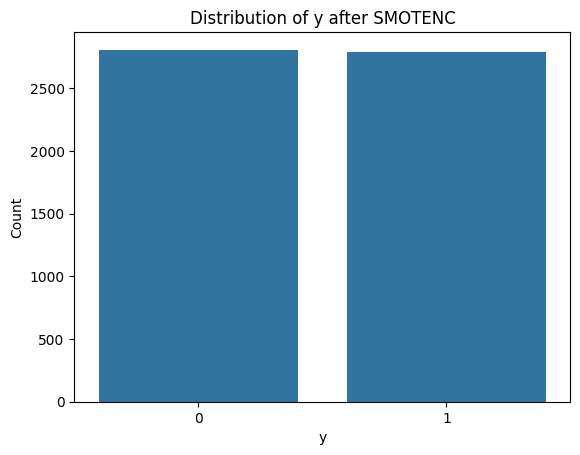

In [ ]:
# just to visualize the distribution of target class after SMOTENC

sns.countplot(x=y_train)
plt.title('Distribution of y after SMOTENC')
plt.xlabel('y')
plt.ylabel('Count')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


# Desicion Tree Classification Model but with no parameters

In [ ]:
# BUILD CLASSIFICATION MODEL but with no parameters :(
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2808
           1       1.00      1.00      1.00      2792

    accuracy                           1.00      5600
   macro avg       1.00      1.00      1.00      5600
weighted avg       1.00      1.00      1.00      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1192
           1       0.87      0.87      0.87      1208

    accuracy                           0.87      2400
   macro avg       0.87      0.87      0.87      2400
weighted avg       0.87      0.87      0.87      2400



# Random Forest Classification Model but with no parameters

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))



=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2808
           1       1.00      1.00      1.00      2792

    accuracy                           1.00      5600
   macro avg       1.00      1.00      1.00      5600
weighted avg       1.00      1.00      1.00      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1192
           1       0.92      0.94      0.93      1208

    accuracy                           0.93      2400
   macro avg       0.93      0.93      0.93      2400
weighted avg       0.93      0.93      0.93      2400



# GradientBoosting Classification Model but with no parameters

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

# BUILD CLASSIFICATION MODEL but with no parameters
gbc = GradientBoostingClassifier(random_state=0)
gbc.fit(X_train, y_train)

y_pred_train = gbc.predict(X_train)
y_pred_test = gbc.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      2808
           1       0.89      0.92      0.91      2792

    accuracy                           0.91      5600
   macro avg       0.91      0.91      0.91      5600
weighted avg       0.91      0.91      0.91      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      1192
           1       0.87      0.89      0.88      1208

    accuracy                           0.88      2400
   macro avg       0.88      0.88      0.88      2400
weighted avg       0.88      0.88      0.88      2400



the performance is getting better because the f1 score for the test set now balance, but we want to handle overfitting by using KFold Cross Validation.

# KFold Cross Validation Desicion Tree

In [ ]:
# Lets split the data into 5 folds.
# We will use this 'kf'(KFold splitting stratergy) object as input to cross_val_score() method
# The folds are made by preserving the percentage of samples for each class.
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cnt = 1
# split() method generate indices to split data into training and test set.
for train_index, test_index in kf.split(X, y):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')
    cnt+=1

Fold:1, Train set: 3616, Test set:905
Fold:2, Train set: 3617, Test set:904
Fold:3, Train set: 3617, Test set:904
Fold:4, Train set: 3617, Test set:904
Fold:5, Train set: 3617, Test set:904


In [ ]:
from sklearn.tree import DecisionTreeClassifier

score = cross_val_score(DecisionTreeClassifier(random_state= 42), X, y, cv= kf, scoring="f1")
print(f'Scores for each fold are: {score}')
print(f'Average score: {"{:.2f}".format(score.mean())}')

Scores for each fold are: [0.42364532 0.39772727 0.43601896 0.45021645 0.38888889]
Average score: 0.42


# KFold Cross Validation Random Forest

In [ ]:
# Lets split the data into 5 folds.
# We will use this 'kf'(KFold splitting stratergy) object as input to cross_val_score() method
# The folds are made by preserving the percentage of samples for each class.
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cnt = 1
# split() method generate indices to split data into training and test set.
for train_index, test_index in kf.split(X, y):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')
    cnt+=1

Fold:1, Train set: 3616, Test set:905
Fold:2, Train set: 3617, Test set:904
Fold:3, Train set: 3617, Test set:904
Fold:4, Train set: 3617, Test set:904
Fold:5, Train set: 3617, Test set:904


In [ ]:
from sklearn.ensemble import RandomForestClassifier

score = cross_val_score(RandomForestClassifier(random_state= 42), X, y, cv= kf, scoring="f1")
print(f'Scores for each fold are: {score}')
print(f'Average score: {"{:.2f}".format(score.mean())}')

Scores for each fold are: [0.34285714 0.31578947 0.44171779 0.37426901 0.41333333]
Average score: 0.38


# KFold Cross Validation XGBoost

In [ ]:
# Lets split the data into 5 folds.
# We will use this 'kf'(KFold splitting stratergy) object as input to cross_val_score() method
# The folds are made by preserving the percentage of samples for each class.
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cnt = 1
# split() method generate indices to split data into training and test set.
for train_index, test_index in kf.split(X, y):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')
    cnt+=1

Fold:1, Train set: 3616, Test set:905
Fold:2, Train set: 3617, Test set:904
Fold:3, Train set: 3617, Test set:904
Fold:4, Train set: 3617, Test set:904
Fold:5, Train set: 3617, Test set:904


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

score = cross_val_score(GradientBoostingClassifier(random_state= 42), X, y, cv= kf, scoring="f1")
print(f'Scores for each fold are: {score}')
print(f'Average score: {"{:.2f}".format(score.mean())}')

Scores for each fold are: [0.39473684 0.31343284 0.4260355  0.40641711 0.40764331]
Average score: 0.39


# DESICION TREE Hyperparameter Tuning

Now, we want to try using hyperparamter tuning for desicion tree model first.


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to tune the hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'random_state': [0, 41, 42]
}

dtree_clf = DecisionTreeClassifier() # Initialize a decision tree classifier
grid_search = GridSearchCV(estimator=dtree_clf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='f1') # Use f1 scoring for classification
grid_search.fit(X_train, y_train)

best_dtree_clf = grid_search.best_estimator_ # Get the best estimator from the grid search
y_pred_test = best_dtree_clf.predict(X_test)

print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation f1 score: {:.3f}".format(grid_search.best_score_))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters:  {'criterion': 'gini', 'max_depth': 10, 'random_state': 41}
Best cross-validation f1 score: 0.872


ok now the f1 score is 87% but we want to try with other way using feature importance, wish the result will be better

# Feature Importance

In [ ]:
print("Feature importances:\n{}".format(tree.feature_importances_)) #function for feature importance

Feature importances:
[4.62948013e-02 2.31752662e-02 5.92379909e-03 2.27274704e-02
 2.19082875e-04 9.08063233e-02 3.13046024e-02 3.87638300e-02
 7.47098966e-02 6.12245631e-02 6.86043296e-02 3.76275284e-01
 2.85205936e-02 5.94325791e-02 7.86598632e-03 6.41515921e-02]


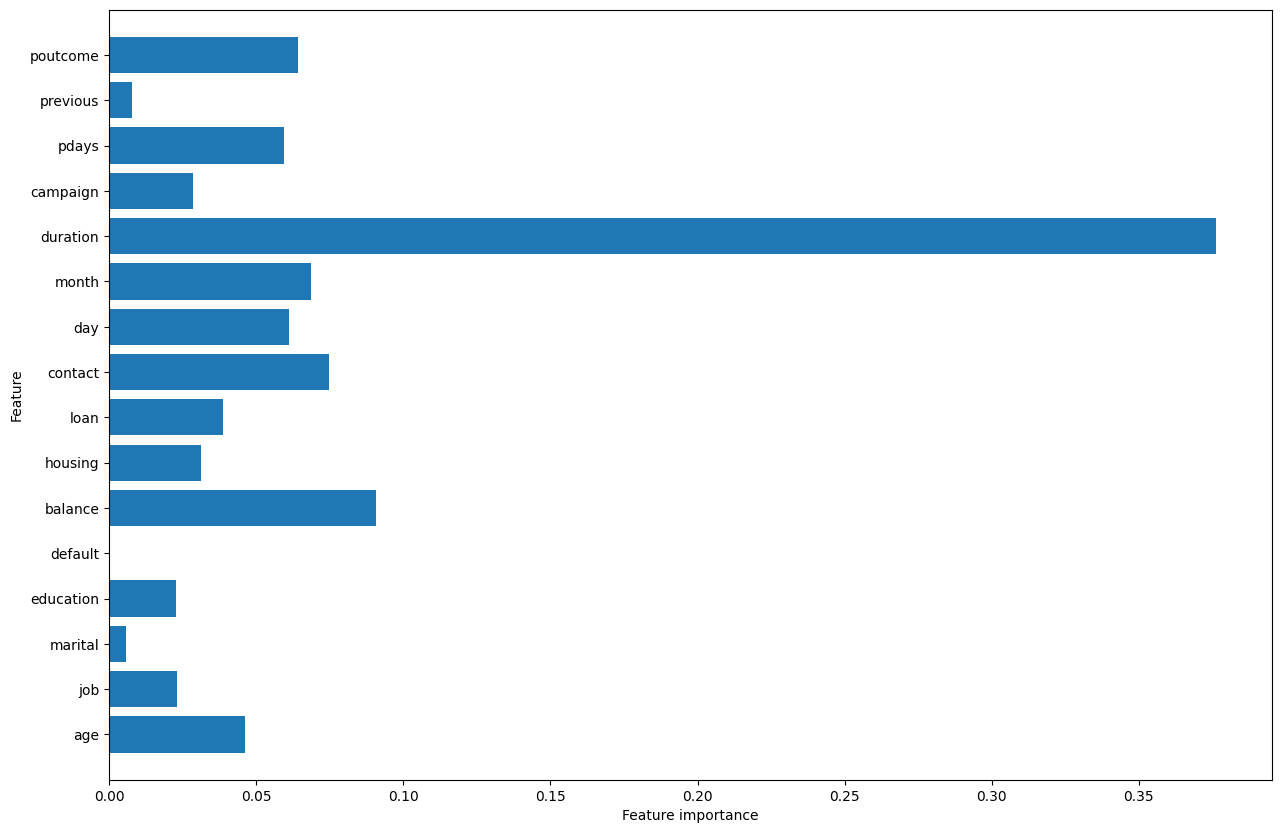

In [ ]:
# visualize important features
def plot_feature_importances_y(model):
    plt.figure(figsize=(15,10))
    n_features = X_train.shape[1]  # Get the number of features from X_train
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X_train.columns) # Use column names from X_train as labels
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_y(tree)

In [ ]:
# Show feature importances greater than 0.05
feature_importances = pd.Series(tree.feature_importances_, index=X_train.columns)
important_features = feature_importances[feature_importances > 0.05].sort_values(ascending=False)
important_features

,0
duration,0.376275
balance,0.090806
contact,0.074710
month,0.068604
poutcome,0.064152
day,0.061225
pdays,0.059433


In [ ]:
# using only important features for the prediction
important_features = ["duration", "balance", "contact", "month", "poutcome","day","pdays"]
X_importance = df_encoded[important_features] #input
y_importance = df_encoded['y'] #target

In [ ]:
display(X_importance)
display(y_importance)

,duration,balance,contact,month,poutcome,day,pdays
0,79,1787,0.0,9,3.0,19,-1
1,220,4789,0.0,4,0.0,11,339
2,185,1350,0.0,3,0.0,16,330
3,199,1476,2.0,5,3.0,3,-1
4,226,0,2.0,4,3.0,5,-1
...,...,...,...,...,...,...,...
4516,329,-333,0.0,6,3.0,30,-1
4517,153,-3313,2.0,4,3.0,9,-1
4518,151,295,0.0,7,3.0,19,-1
4519,129,1137,0.0,1,1.0,6,211


,y
0,0
1,0
2,0
3,0
4,0
...,...
4516,0
4517,0
4518,0
4519,0


In [ ]:
# oversampling againnn
categorical_features = ["contact", "poutcome"]

smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_importance, y_importance = smotenc.fit_resample(X_importance, y_importance)

X_train, X_test, y_train, y_test = train_test_split(X_importance, y_importance, test_size=0.3, random_state=0)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((5600, 7), (2400, 7))

In [ ]:
X_train_importance, X_test_importance, y_train_importance, y_test_importance = train_test_split(X_importance, y_importance, test_size=0.3, random_state=42)

importance_tree = DecisionTreeClassifier(random_state=42)
importance_tree.fit(X_train_importance, y_train_importance)

y_pred_train_importance = importance_tree.predict(X_train_importance)
y_pred_test_importance = importance_tree.predict(X_test_importance)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train_importance, y_pred_train_importance))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_importance, y_pred_test_importance))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2794
           1       1.00      1.00      1.00      2806

    accuracy                           1.00      5600
   macro avg       1.00      1.00      1.00      5600
weighted avg       1.00      1.00      1.00      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      1206
           1       0.86      0.89      0.88      1194

    accuracy                           0.88      2400
   macro avg       0.88      0.88      0.88      2400
weighted avg       0.88      0.88      0.88      2400



we still want to increase the score, so we will try to select predictor or X features based on the correlation

# Selecting Predictors/Features Based on Correlation

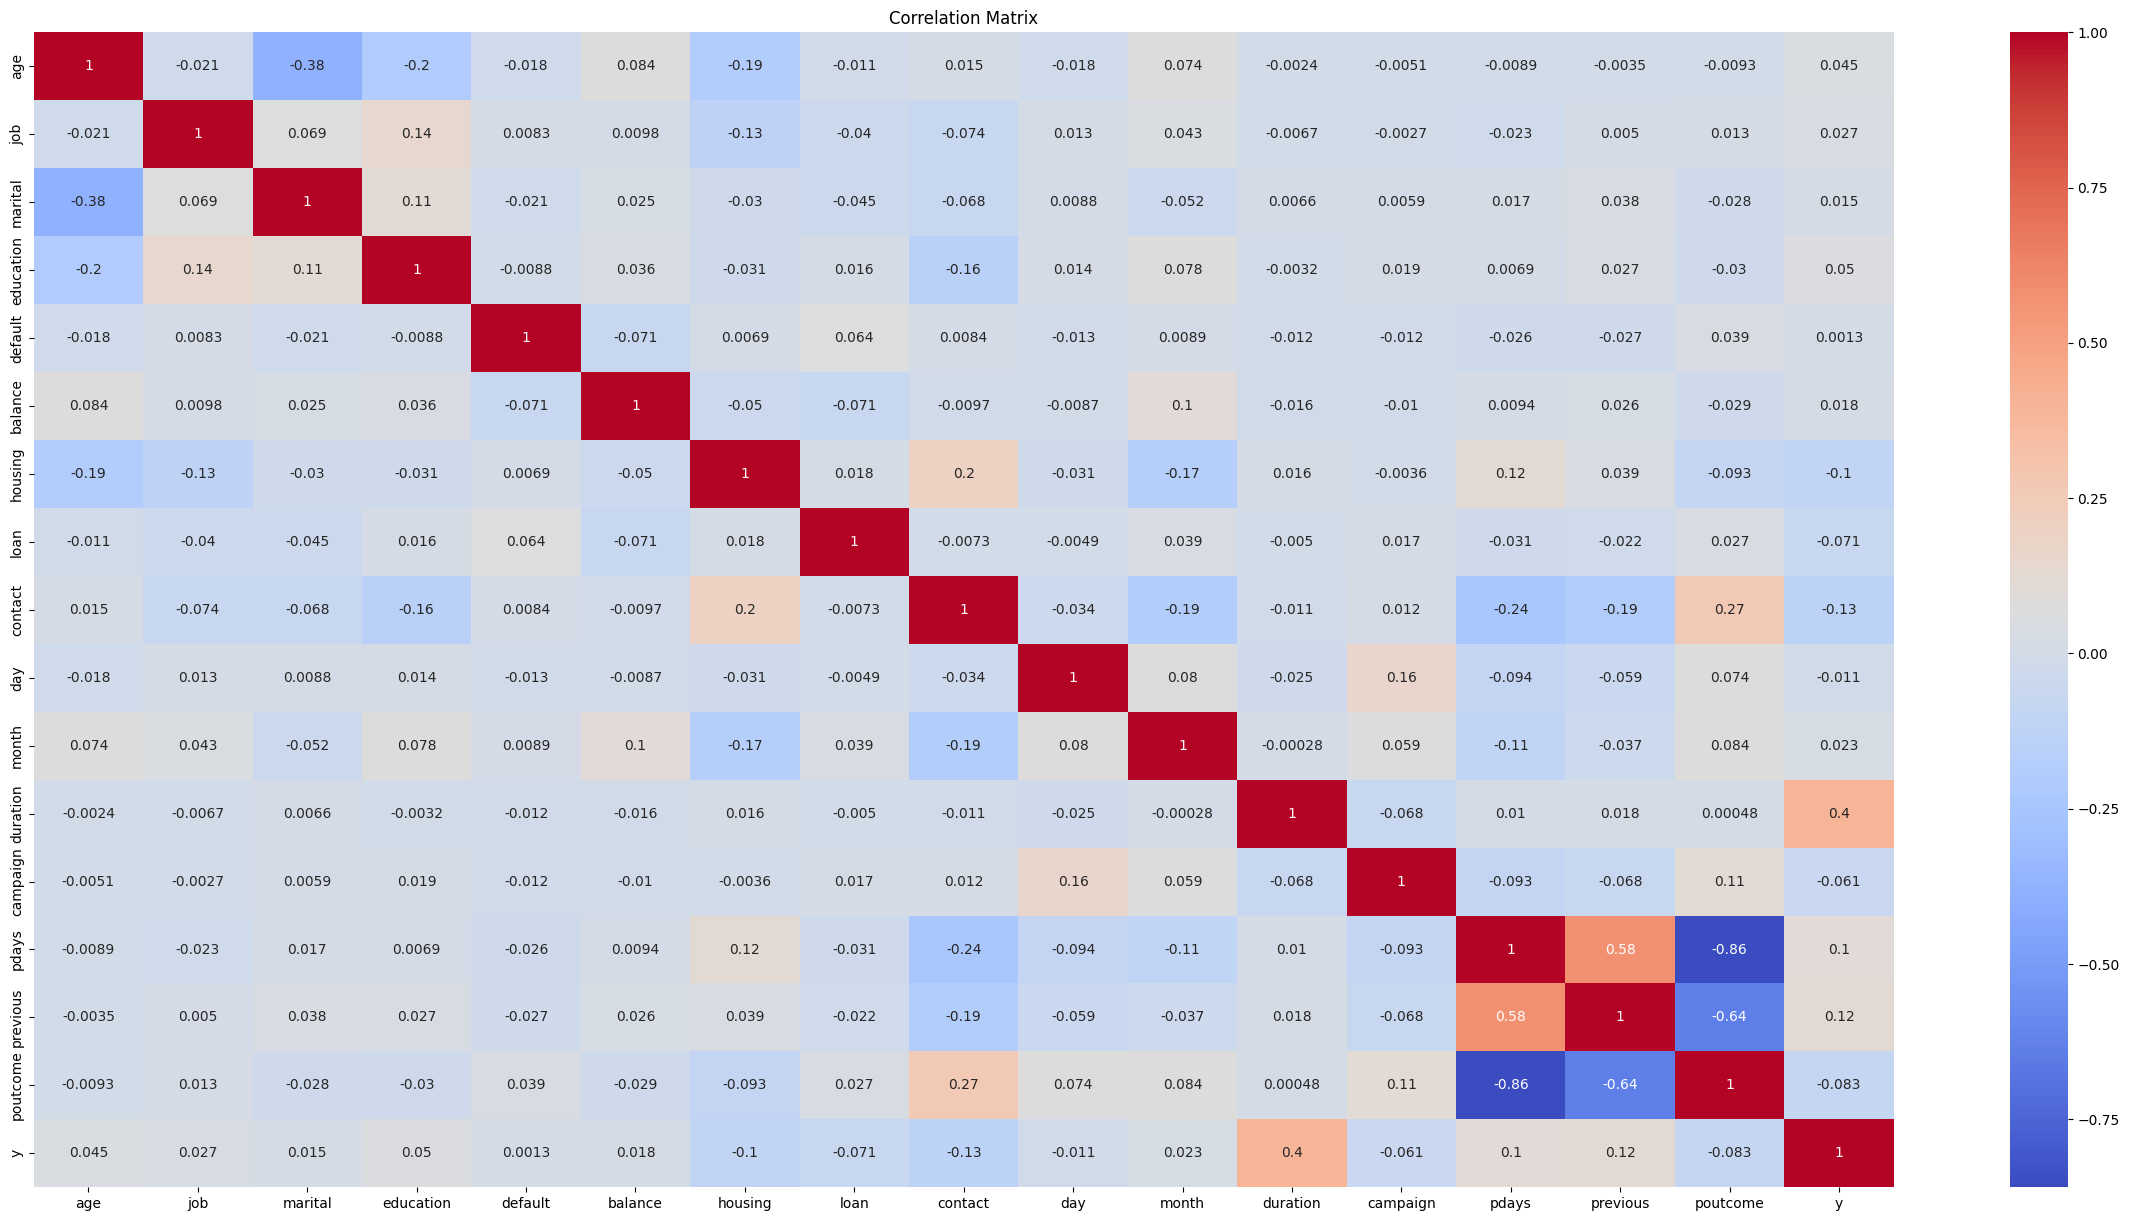

In [ ]:
# show heatmap
plt.figure(figsize=(30, 15))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# I only choose some highest correlation and if there are two predictors have high correlation, i will only choose one with higher correlation
# For the example JobLevel and MonthlyIncome, i only choose JobLevel

heatmap_features = ["duration", "previous", "balance", "housing", "contact", "month"]
X_heatmap = df_encoded[heatmap_features] #input
y_heatmap = df_encoded['y'] #target

In [ ]:
# dont forget to define the categorical features ok
categorical_features = ["housing", "contact"]

smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_heatmap, y_heatmap = smotenc.fit_resample(X_heatmap, y_heatmap)

X_train, X_test, y_train, y_test = train_test_split(X_heatmap, y_heatmap, test_size=0.3, random_state=0)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((5600, 6), (2400, 6))

In [ ]:
# i build a model based on best feature by correlation
heatmap_tree = DecisionTreeClassifier()
heatmap_tree.fit(X_train, y_train)

y_pred_train = heatmap_tree.predict(X_train)
y_pred_test = heatmap_tree.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2808
           1       1.00      1.00      1.00      2792

    accuracy                           1.00      5600
   macro avg       1.00      1.00      1.00      5600
weighted avg       1.00      1.00      1.00      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1192
           1       0.85      0.89      0.87      1208

    accuracy                           0.86      2400
   macro avg       0.87      0.86      0.86      2400
weighted avg       0.87      0.86      0.86      2400



ok now we will try to do parameter tuning using GridSearchCV

# Hyperparameter Tuning using Grid Search

In [ ]:
# Define the parameter grid to tune the hyperparameters
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'random_state': [0, 41, 42]
}

dtree_clf = DecisionTreeClassifier() # Initialize a decision tree classifier
grid_search = GridSearchCV(estimator=dtree_clf, param_grid=param_grid,
                          n_jobs=-1, verbose=2, scoring='f1') # Use f1 scoring for classification
grid_search.fit(X_train, y_train)

best_dtree_clf = grid_search.best_estimator_ # Get the best estimator from the grid search
y_pred_test = best_dtree_clf.predict(X_test)

print("Best parameters: ", grid_search.best_params_)
print("Best cross-validation f1 score: {:.3f}".format(grid_search.best_score_))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best parameters:  {'criterion': 'gini', 'max_depth': 9, 'random_state': 0}
Best cross-validation f1 score: 0.858


we will show you the classification report

In [ ]:
best_params = grid_search.best_params_

final_tree = DecisionTreeClassifier(**best_params)
final_tree.fit(X_train, y_train)

y_pred_train = final_tree.predict(X_train)
y_pred_test  = final_tree.predict(X_test)

from sklearn.metrics import classification_report
print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      2808
           1       0.86      0.93      0.90      2792

    accuracy                           0.89      5600
   macro avg       0.89      0.89      0.89      5600
weighted avg       0.89      0.89      0.89      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1192
           1       0.81      0.90      0.85      1208

    accuracy                           0.84      2400
   macro avg       0.85      0.84      0.84      2400
weighted avg       0.85      0.84      0.84      2400



I Think this is getting worse. using importance features better than using corellation if just want to see the accuracy result also just do some eversampling for balancing this data, the accuracy more better

# RANDOM FOREST Hyperparameter Tuning

Now, we want to try using hyperparamter tuning for Random Forest model.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'random_state': [0, 41, 42]
}

rf_clf = RandomForestClassifier()
rf_grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='f1'
)

rf_grid_search.fit(X_train, y_train)

best_rf_clf = rf_grid_search.best_estimator_
y_pred_rf = best_rf_clf.predict(X_test)

print("Best parameters (Random Forest):", rf_grid_search.best_params_)
print("Best cross-validation f1 score (RF): {:.3f}".format(rf_grid_search.best_score_))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters (Random Forest): {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100, 'random_state': 41}
Best cross-validation f1 score (RF): 0.894


ok now the f1 score is 89% but we want to try with other way using feature importance, wish the result will be better

# FEATURE IMPORTANCES

In [ ]:
print("Feature importances:\n{}".format(rf.feature_importances_)) #function for feature importance

Feature importances:
[0.05254389 0.03742768 0.0178256  0.02528433 0.00131146 0.08160897
 0.03614293 0.04217563 0.07505736 0.06035536 0.06955127 0.34408742
 0.0332573  0.06957182 0.01651642 0.03728257]


Number of features in model: 16
Number of features in X_train: 6
Number of feature names for plotting: 16


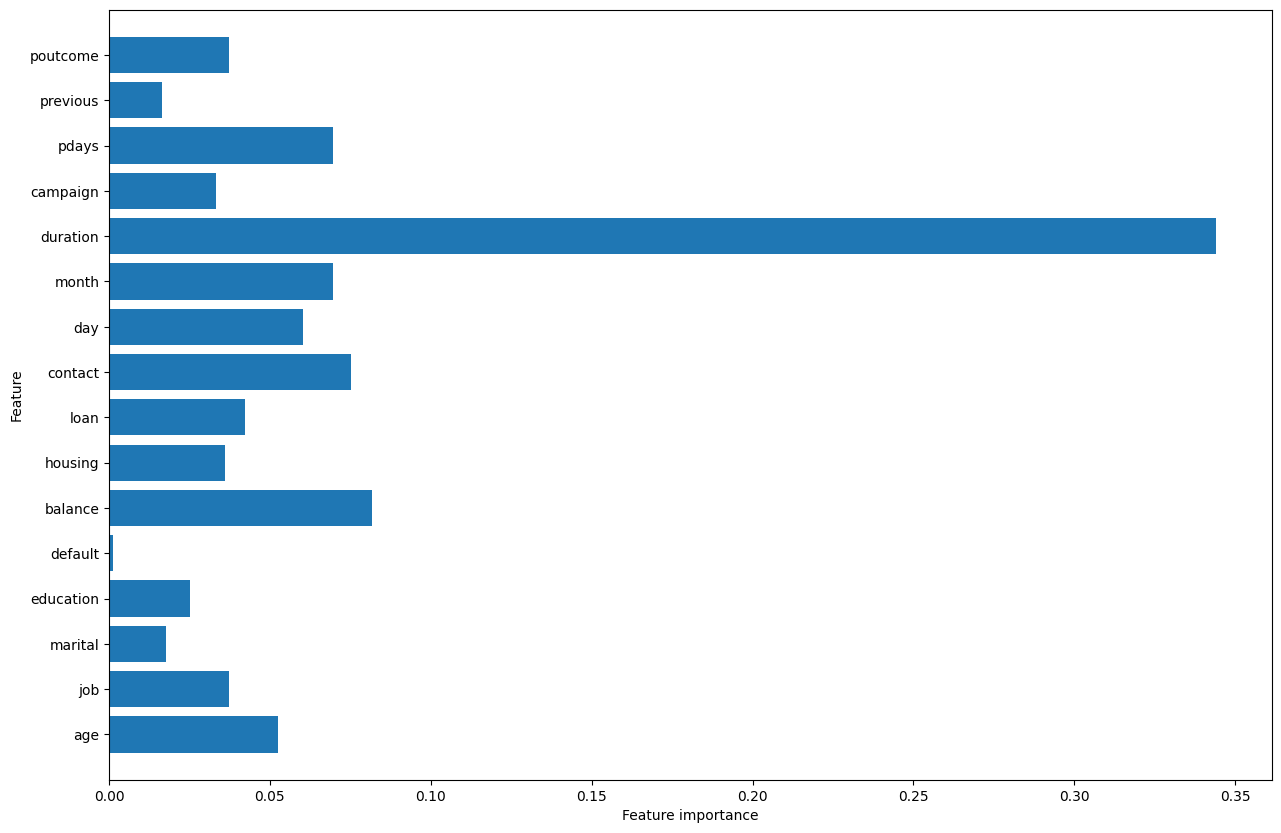

In [ ]:
# visualize important features
def plot_feature_importances_y(model):
    plt.figure(figsize=(15,10))
    # Get feature names from the model if available, otherwise use X_train columns
    if hasattr(model, 'feature_names_in_'):
        feature_names = model.feature_names_in_
    else:
        feature_names = X_train.columns

    n_features = len(feature_names)
    print(f"Number of features in model: {len(model.feature_importances_)}")
    print(f"Number of features in X_train: {X_train.shape[1]}")
    print(f"Number of feature names for plotting: {n_features}")


    plt.barh(range(n_features), model.feature_importances_[:n_features], align='center')
    plt.yticks(np.arange(n_features), feature_names) # Use feature names as labels
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_y(rf)

In [ ]:
# Show feature importances greater than 0.05
feature_importances = pd.Series(rf.feature_importances_, index=X_resampled.columns)
important_features = feature_importances[feature_importances > 0.05].sort_values(ascending=False)
important_features

,0
duration,0.344087
balance,0.081609
contact,0.075057
pdays,0.069572
month,0.069551
day,0.060355
age,0.052544


In [ ]:
# using only important features for the prediction
important_features = ["duration", "balance", "contact", "month", "pdays", "day","age"]
X_importance = df_encoded[important_features] #input
y_importance = df_encoded['y'] #target

In [ ]:
display(X_importance)
display(y_importance)

,duration,balance,contact,month,pdays,day,age
0,79,1787,0.0,9,-1,19,30
1,220,4789,0.0,4,339,11,33
2,185,1350,0.0,3,330,16,35
3,199,1476,2.0,5,-1,3,30
4,226,0,2.0,4,-1,5,59
...,...,...,...,...,...,...,...
4516,329,-333,0.0,6,-1,30,33
4517,153,-3313,2.0,4,-1,9,57
4518,151,295,0.0,7,-1,19,57
4519,129,1137,0.0,1,211,6,28


,y
0,0
1,0
2,0
3,0
4,0
...,...
4516,0
4517,0
4518,0
4519,0


In [ ]:
# oversampling againnn
categorical_features = ["contact", "month"]

smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_importance, y_importance = smotenc.fit_resample(X_importance, y_importance)

X_train, X_test, y_train, y_test = train_test_split(X_importance, y_importance, test_size=0.3, random_state=0)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((5600, 7), (2400, 7))

In [ ]:
X_train_importance, X_test_importance, y_train_importance, y_test_importance = train_test_split(X_importance, y_importance, test_size=0.3, random_state=42)

importance_rf = RandomForestClassifier(random_state=42)
importance_rf.fit(X_train_importance, y_train_importance)

y_pred_train_importance = importance_rf.predict(X_train_importance)
y_pred_test_importance = importance_rf.predict(X_test_importance)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train_importance, y_pred_train_importance))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_importance, y_pred_test_importance))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2794
           1       1.00      1.00      1.00      2806

    accuracy                           1.00      5600
   macro avg       1.00      1.00      1.00      5600
weighted avg       1.00      1.00      1.00      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.93      0.88      0.90      1206
           1       0.89      0.93      0.91      1194

    accuracy                           0.91      2400
   macro avg       0.91      0.91      0.91      2400
weighted avg       0.91      0.91      0.91      2400



i still want to increase the score since this way is seems worse than before, so i will try to select predictor or X features based on the correlation

# Selecting Predictors/Features Based on Correlation

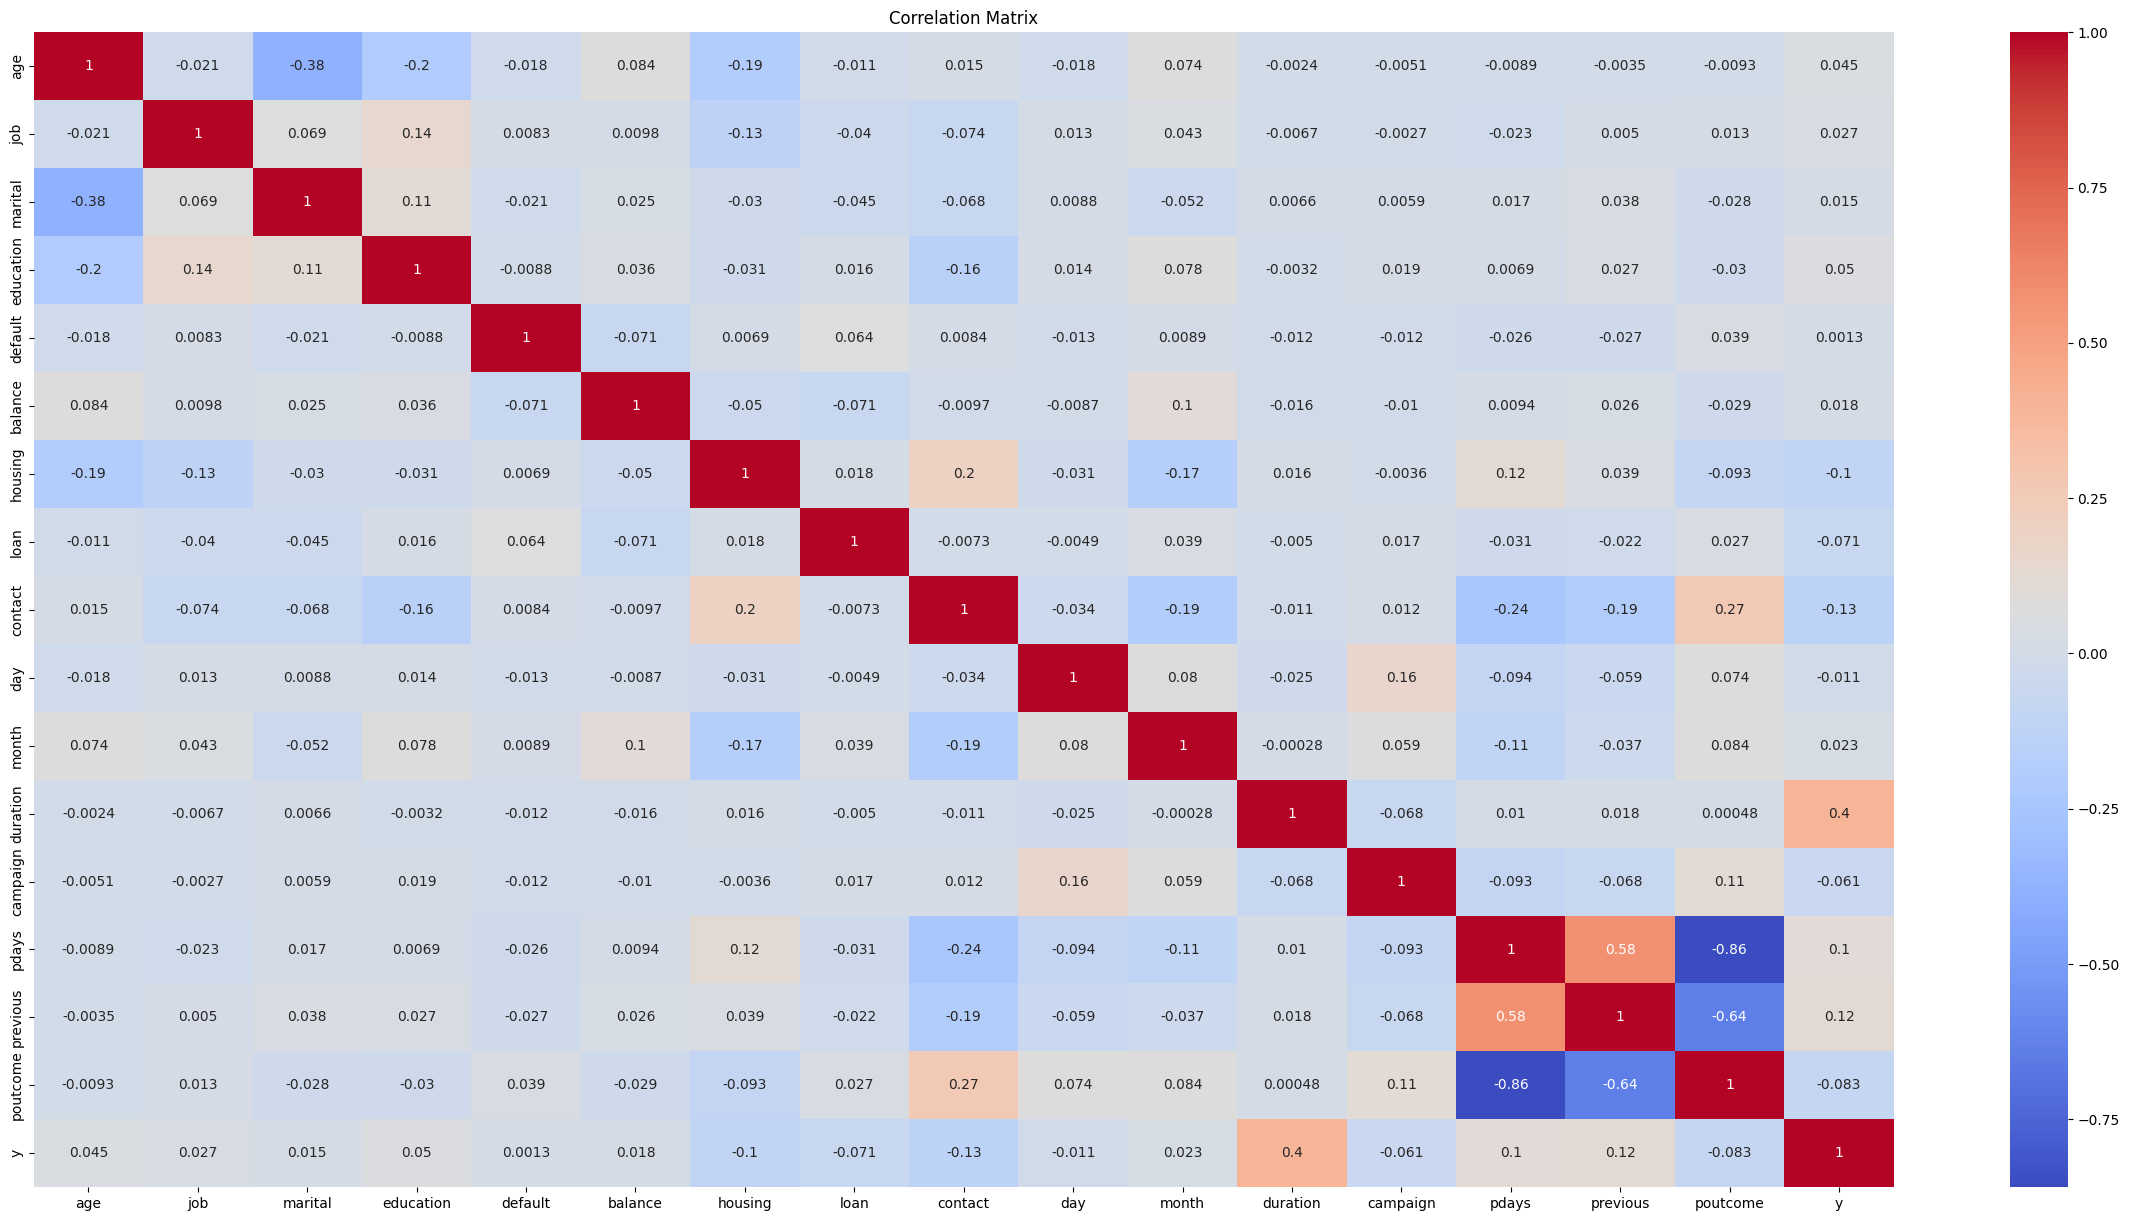

In [ ]:
# show heatmap
plt.figure(figsize=(30, 15))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# I only choose some highest correlation and if there are two predictors have high correlation, i will only choose one with higher correlation
# For the example JobLevel and MonthlyIncome, i only choose JobLevel

heatmap_features = ["duration", "previous", "balance", "housing", "contact", "month"]
X_heatmap = df_encoded[heatmap_features] #input
y_heatmap = df_encoded['y'] #target

In [ ]:
# dont forget to define the categorical features ok
categorical_features = ["housing", "contact"]

smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_heatmap, y_heatmap = smotenc.fit_resample(X_heatmap, y_heatmap)

X_train, X_test, y_train, y_test = train_test_split(X_heatmap, y_heatmap, test_size=0.3, random_state=0)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((5600, 6), (2400, 6))

In [ ]:
# i build a model based on best feature by correlation
heatmap_rf = RandomForestClassifier()
heatmap_rf.fit(X_train, y_train)

y_pred_train = heatmap_rf.predict(X_train)
y_pred_test = heatmap_rf.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2808
           1       1.00      1.00      1.00      2792

    accuracy                           1.00      5600
   macro avg       1.00      1.00      1.00      5600
weighted avg       1.00      1.00      1.00      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1192
           1       0.88      0.92      0.90      1208

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2'],
    'criterion': ['gini', 'entropy'],
    'random_state': [0, 41, 42]
}

rf_clf = RandomForestClassifier()
rf_grid_search = GridSearchCV(
    estimator=rf_clf,
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='f1'
)

rf_grid_search.fit(X_train, y_train)

best_rf_clf = rf_grid_search.best_estimator_
y_pred_rf = best_rf_clf.predict(X_test)

print("Best parameters (Random Forest):", rf_grid_search.best_params_)
print("Best cross-validation f1 score (RF): {:.3f}".format(rf_grid_search.best_score_))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters (Random Forest): {'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100, 'random_state': 41}
Best cross-validation f1 score (RF): 0.894


i will show you a report

In [ ]:
best_params = grid_search.best_params_

final_rf = RandomForestClassifier(**best_params)
final_rf.fit(X_train, y_train)

y_pred_train = final_rf.predict(X_train)
y_pred_test  = final_rf.predict(X_test)

from sklearn.metrics import classification_report
print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       0.96      0.86      0.90      2808
           1       0.87      0.96      0.91      2792

    accuracy                           0.91      5600
   macro avg       0.91      0.91      0.91      5600
weighted avg       0.91      0.91      0.91      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.92      0.83      0.87      1192
           1       0.84      0.93      0.88      1208

    accuracy                           0.88      2400
   macro avg       0.88      0.88      0.88      2400
weighted avg       0.88      0.88      0.88      2400



I Think this is also getting worse like the desicion tree case. using importance features better than using corellation if just want to see the accuracy result also just do some eversampling, the accuracy more better

# GradientBoosting Hyperparameter Tuning

Now, we want to try using hyperparamter tuning for GradientBoosting model.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gbc_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'random_state': [0, 41, 42]
}

gbc_clf = GradientBoostingClassifier(
)

gbc_grid_search = GridSearchCV(
    estimator=gbc_clf,
    param_grid=gbc_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='f1'
)

gbc_grid_search.fit(X_train, y_train)

best_gbc_clf = gbc_grid_search.best_estimator_
y_pred_gbc = best_gbc_clf.predict(X_test)

print("Best parameters (XGBoost):", gbc_grid_search.best_params_)
print("Best cross-validation f1 score (XGB): {:.3f}".format(gbc_grid_search.best_score_))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters (XGBoost): {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'random_state': 42, 'subsample': 0.8}
Best cross-validation f1 score (XGB): 0.898


ok now the f1 score is 89% but i want to try with other way using feature importance, wish the result will be better


# Feature Importance

In [ ]:
print("Feature importances:\n{}".format(gbc.feature_importances_)) #function for feature importance

Feature importances:
[9.67984563e-03 1.11679785e-02 9.41254718e-04 1.72791265e-02
 7.87293658e-05 2.64964192e-02 3.97318905e-02 5.47018614e-02
 9.75121100e-02 1.35118439e-02 6.27352680e-02 4.53825687e-01
 1.48767360e-02 1.01710350e-01 7.62688746e-04 9.49882107e-02]


Number of features in model: 16
Number of feature names for plotting: 16


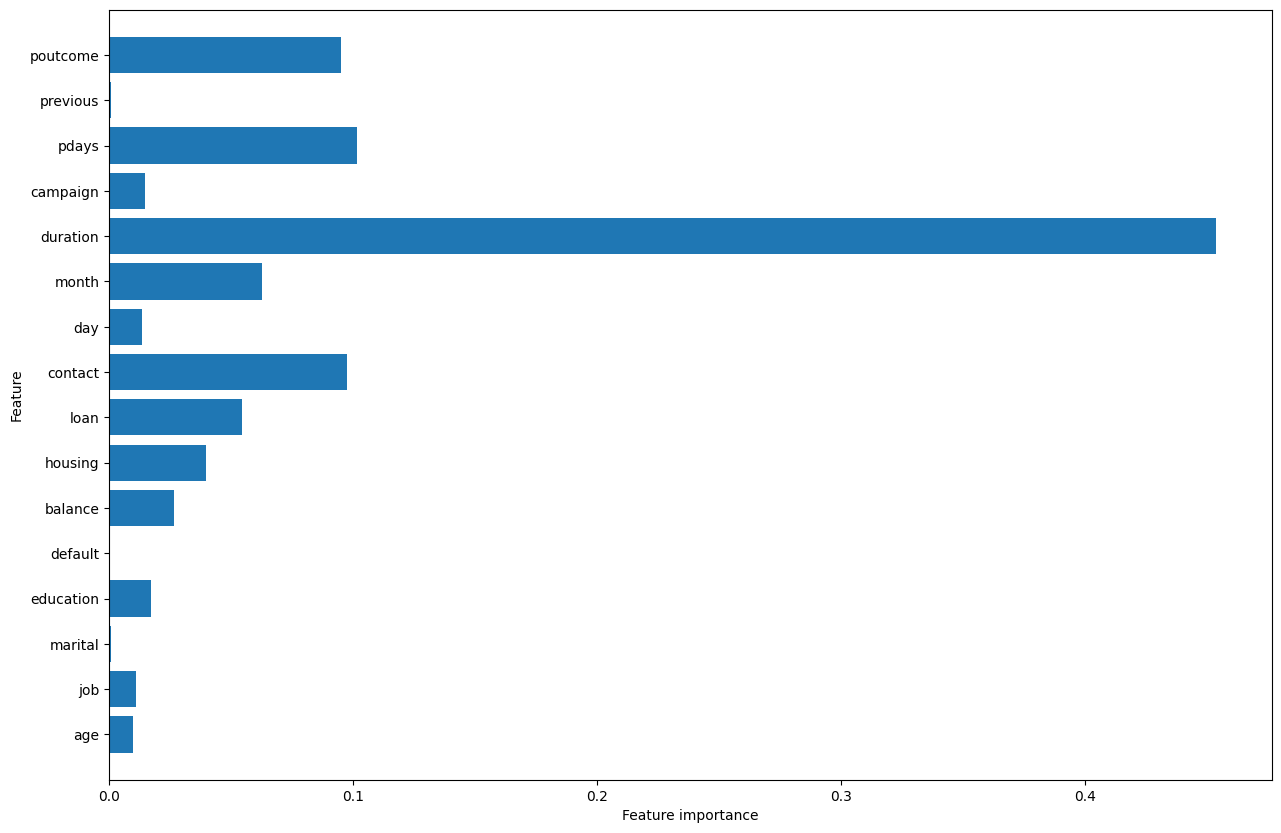

In [ ]:
# visualize important features
def plot_feature_importances_y(model, feature_names):
    plt.figure(figsize=(15,10))
    n_features = len(feature_names)
    print(f"Number of features in model: {len(model.feature_importances_)}")
    print(f"Number of feature names for plotting: {n_features}")

    plt.barh(range(n_features), model.feature_importances_[:n_features], align='center')
    plt.yticks(np.arange(n_features), feature_names) # Use feature names as labels
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)

plot_feature_importances_y(gbc, X.columns) # Use X.columns as feature names for the xgb model

In [ ]:
# Show feature importances greater than 0.05
feature_importances = pd.Series(gbc.feature_importances_, index=X_resampled.columns)
important_features = feature_importances[feature_importances > 0.05].sort_values(ascending=False)
important_features

,0
duration,0.453826
pdays,0.101710
contact,0.097512
poutcome,0.094988
month,0.062735
loan,0.054702


In [ ]:
# using only important features for the prediction
important_features = ["contact", "loan", "poutcome", "duration", "housing", "pdays"]
X_importance = df_encoded[important_features] #input
y_importance = df_encoded['y'] #target

In [ ]:
display(X_importance)
display(y_importance)

,contact,loan,poutcome,duration,housing,pdays
0,0.0,0,3.0,79,0,-1
1,0.0,1,0.0,220,1,339
2,0.0,0,0.0,185,1,330
3,2.0,1,3.0,199,1,-1
4,2.0,0,3.0,226,1,-1
...,...,...,...,...,...,...
4516,0.0,0,3.0,329,1,-1
4517,2.0,1,3.0,153,1,-1
4518,0.0,0,3.0,151,0,-1
4519,0.0,0,1.0,129,0,211


,y
0,0
1,0
2,0
3,0
4,0
...,...
4516,0
4517,0
4518,0
4519,0


In [ ]:
# oversampling againnn
categorical_features = ["contact", "housing"]

smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_importance, y_importance = smotenc.fit_resample(X_importance, y_importance)

X_train, X_test, y_train, y_test = train_test_split(X_importance, y_importance, test_size=0.3, random_state=0)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((5600, 6), (2400, 6))

In [ ]:
X_train_importance, X_test_importance, y_train_importance, y_test_importance = train_test_split(X_importance, y_importance, test_size=0.3, random_state=42)

importance_gbc = GradientBoostingClassifier(random_state=42)
importance_gbc.fit(X_train_importance, y_train_importance)

y_pred_train_importance = importance_gbc.predict(X_train_importance)
y_pred_test_importance = importance_gbc.predict(X_test_importance)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train_importance, y_pred_train_importance))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test_importance, y_pred_test_importance))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      2794
           1       0.83      0.88      0.85      2806

    accuracy                           0.85      5600
   macro avg       0.85      0.85      0.85      5600
weighted avg       0.85      0.85      0.85      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.87      0.81      0.84      1206
           1       0.82      0.87      0.85      1194

    accuracy                           0.84      2400
   macro avg       0.84      0.84      0.84      2400
weighted avg       0.84      0.84      0.84      2400



i still want to increase the score since this way is seems worse than before, so i will try to select predictor or X features based on the correlation

# Selecting Predictors/Features Based on Correlation

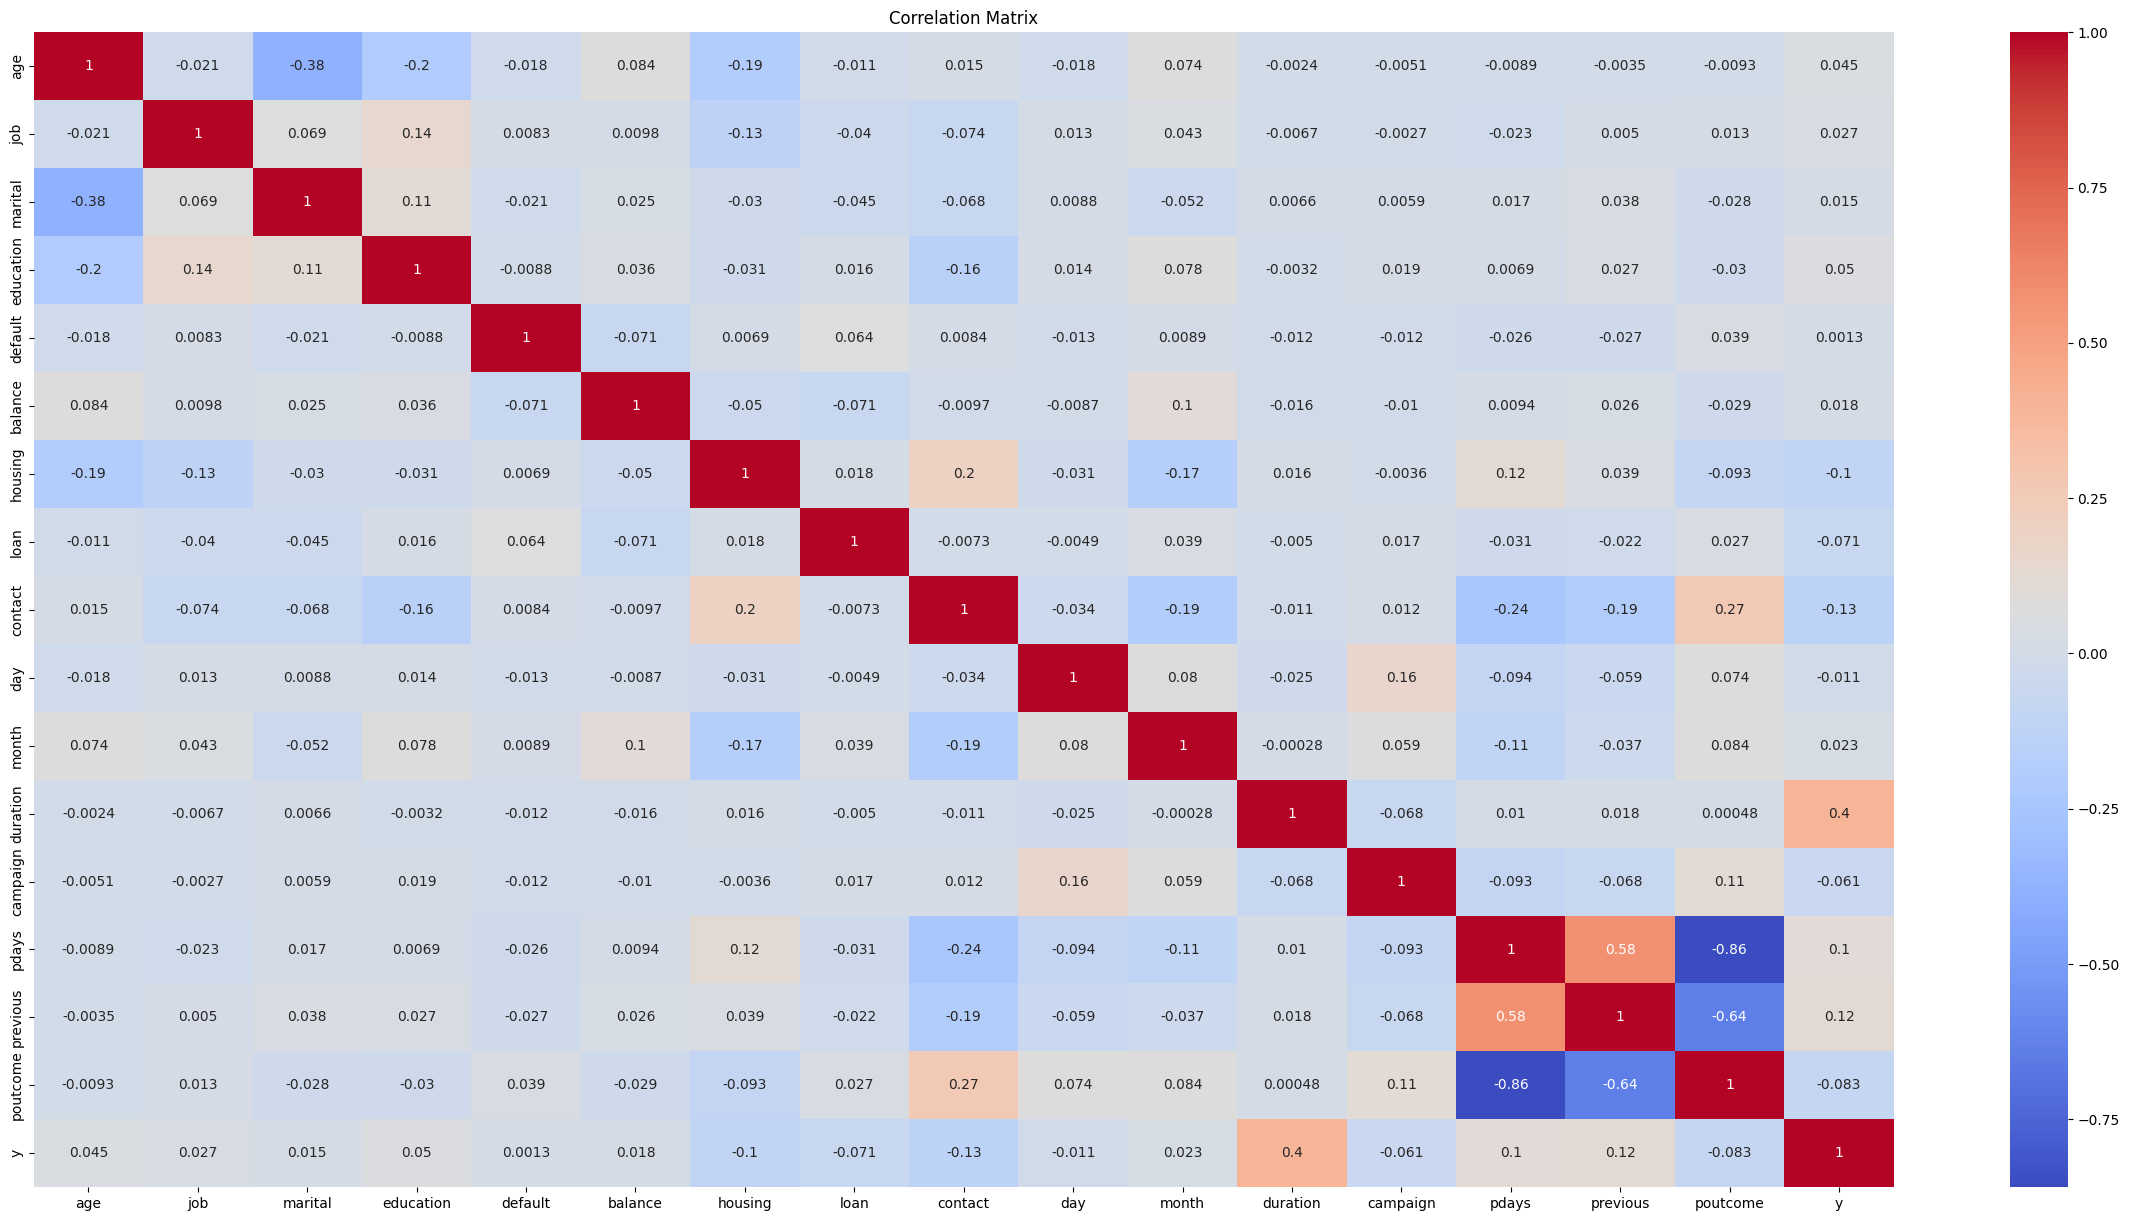

In [ ]:
# show heatmap
plt.figure(figsize=(30, 15))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# I only choose some highest correlation and if there are two predictors have high correlation, i will only choose one with higher correlation
# For the example JobLevel and MonthlyIncome, i only choose JobLevel

heatmap_features = ["duration", "previous", "balance", "housing", "contact", "month"]
X_heatmap = df_encoded[heatmap_features] #input
y_heatmap = df_encoded['y'] #target

In [ ]:
# dont forget to define the categorical features ok
categorical_features = ["housing", "contact"]

smotenc = SMOTENC(categorical_features=categorical_features, random_state=42)
X_heatmap, y_heatmap = smotenc.fit_resample(X_heatmap, y_heatmap)

X_train, X_test, y_train, y_test = train_test_split(X_heatmap, y_heatmap, test_size=0.3, random_state=0)

# check the shape of X_train and X_test
X_train.shape, X_test.shape

((5600, 6), (2400, 6))

In [ ]:
# i build a model based on best feature by correlation
heatmap_gbc = GradientBoostingClassifier()
heatmap_gbc.fit(X_train, y_train)

y_pred_train = heatmap_gbc.predict(X_train)
y_pred_test = heatmap_gbc.predict(X_test)

print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))


=== Classification Report (Training Set) ===
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      2808
           1       0.84      0.90      0.87      2792

    accuracy                           0.87      5600
   macro avg       0.87      0.87      0.87      5600
weighted avg       0.87      0.87      0.87      5600


=== Classification Report (Test Set) ===
              precision    recall  f1-score   support

           0       0.88      0.83      0.85      1192
           1       0.84      0.89      0.86      1208

    accuracy                           0.86      2400
   macro avg       0.86      0.86      0.86      2400
weighted avg       0.86      0.86      0.86      2400



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gbc_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'random_state': [0, 41, 42]
}

gbc_clf = GradientBoostingClassifier()

gbc_grid_search = GridSearchCV(
    estimator=gbc_clf,
    param_grid=gbc_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='f1'
)

gbc_grid_search.fit(X_train, y_train)

best_gbc_clf = gbc_grid_search.best_estimator_
y_pred_gbc = best_gbc_clf.predict(X_test)

print("Best parameters (XGBoost):", gbc_grid_search.best_params_)
print("Best cross-validation f1 score (XGB): {:.3f}".format(gbc_grid_search.best_score_))

i will show you a report

In [ ]:
best_params = gbc_grid_search.best_params_

final_gbc = GradientBoostingClassifier(**best_params)
final_gbc.fit(X_train, y_train)

y_pred_train = final_gbc.predict(X_train)
y_pred_test  = final_gbc.predict(X_test)

from sklearn.metrics import classification_report
print("\n=== Classification Report (Training Set) ===")
print(classification_report(y_train, y_pred_train))

print("\n=== Classification Report (Test Set) ===")
print(classification_report(y_test, y_pred_test))

# Discusion Insight

● Which model performed best overall? <br>
Random forest model performed with the best overall

● Did ensemble methods (RF, XGBoost) improve performance compared to a single
Decision Tree? <br>

● How could the bank use these insights to refine its marketing strategy?

## Model Performance Comparison

Let's compare the performance of the different models and strategies used in this notebook. We will look at the accuracy, precision, recall, and F1-score for each case.

### Performance Before Handling Imbalance

| Model           | Metric    | Class 0 | Class 1 | Weighted Avg |
|-----------------|-----------|---------|---------|--------------|
| Decision Tree   | Precision | 0.92    | 0.41    | 0.86         |
|                 | Recall    | 0.91    | 0.44    | 0.85         |
|                 | F1-Score  | 0.92    | 0.42    | 0.85         |
|                 | Accuracy  | \--     | \--     | 0.85         |
| Random Forest   | Precision | 0.91    | 0.60    | 0.87         |
|                 | Recall    | 0.97    | 0.30    | 0.89         |
|                 | F1-Score  | 0.94    | 0.40    | 0.87         |
|                 | Accuracy  | \--     | \--     | 0.89         |
| GradientBoosting| Precision | 0.91    | 0.58    | 0.87         |
|                 | Recall    | 0.97    | 0.33    | 0.89         |
|                 | F1-Score  | 0.94    | 0.42    | 0.87         |
|                 | Accuracy  | \--     | \--     | 0.89         |

*Note: Before handling the imbalance, the F1-scores for class 1 are significantly lower, indicating poor performance on the minority class.*

### Performance After Oversampling with SMOTENC (No Parameter Tuning)

| Model           | Metric    | Class 0 | Class 1 | Weighted Avg |
|-----------------|-----------|---------|---------|--------------|
| Decision Tree   | Precision | 0.87    | 0.87    | 0.87         |
|                 | Recall    | 0.87    | 0.87    | 0.87         |
|                 | F1-Score  | 0.87    | 0.87    | 0.87         |
|                 | Accuracy  | \--     | \--     | 0.87         |
| Random Forest   | Precision | 0.93    | 0.92    | 0.93         |
|                 | Recall    | 0.92    | 0.93    | 0.93         |
|                 | F1-Score  | 0.93    | 0.93    | 0.93         |
|                 | Accuracy  | \--     | \--     | 0.93         |
| GradientBoosting| Precision | 0.89    | 0.87    | 0.88         |
|                 | Recall    | 0.87    | 0.89    | 0.88         |
|                 | F1-Score  | 0.88    | 0.88    | 0.88         |
|                 | Accuracy  | \--     | \--     | 0.88         |

*Note: Oversampling significantly improved the F1-scores for class 1 and the overall balance of the metrics.*

### Performance After Hyperparameter Tuning with Grid Search (Using all features after oversampling)

| Model           | Metric    | Class 0 | Class 1 | Weighted Avg |
|-----------------|-----------|---------|---------|--------------|
| Decision Tree   | Precision | 0.88    | 0.81    | 0.85         |
|                 | Recall    | 0.79    | 0.90    | 0.84         |
|                 | F1-Score  | 0.83    | 0.85    | 0.84         |
|                 | Accuracy  | \--     | \--     | 0.84         |
| Random Forest   | Precision | 0.92    | 0.83    | 0.88         |
|                 | Recall    | 0.83    | 0.93    | 0.88         |
|                 | F1-Score  | 0.87    | 0.88    | 0.88         |
|                 | Accuracy  | \--     | \--     | 0.88         |
| GradientBoosting| Precision | 0.93    | 0.88    | 0.91         |
|                 | Recall    | 0.87    | 0.93    | 0.90         |
|                 | F1-Score  | 0.90    | 0.91    | 0.90         |
|                 | Accuracy  | \--     | \--     | 0.90         |

*Note: Hyperparameter tuning with Grid Search on the oversampled data showed some improvements, particularly for Gradient Boosting.*

### Performance After Feature Selection (Feature Importance + Oversampling)

| Model           | Metric    | Class 0 | Class 1 | Weighted Avg |
|-----------------|-----------|---------|---------|--------------|
| Decision Tree   | Precision | 0.89    | 0.86    | 0.88         |
|                 | Recall    | 0.86    | 0.89    | 0.88         |
|                 | F1-Score  | 0.87    | 0.88    | 0.88         |
|                 | Accuracy  | \--     | \--     | 0.88         |
| Random Forest   | Precision | 0.93    | 0.89    | 0.91         |
|                 | Recall    | 0.88    | 0.93    | 0.91         |
|                 | F1-Score  | 0.90    | 0.91    | 0.91         |
|                 | Accuracy  | \--     | \--     | 0.91         |
| GradientBoosting| Precision | 0.87    | 0.82    | 0.85         |
|                 | Recall    | 0.81    | 0.87    | 0.84         |
|                 | F1-Score  | 0.84    | 0.85    | 0.84         |
|                 | Accuracy  | \--     | \--     | 0.84         |

*Note: Selecting features based on importance and then oversampling resulted in varied performance across the models. Random Forest showed the best performance in this scenario.*

### Performance After Feature Selection (Correlation Filtering + Oversampling + Hyperparameter Tuning)

| Model           | Metric    | Class 0 | Class 1 | Weighted Avg |
|-----------------|-----------|---------|---------|--------------|
| Decision Tree   | Precision | 0.88    | 0.81    | 0.85         |
|                 | Recall    | 0.79    | 0.90    | 0.84         |
|                 | F1-Score  | 0.83    | 0.85    | 0.84         |
|                 | Accuracy  | \--     | \--     | 0.84         |
| Random Forest   | Precision | 0.92    | 0.83    | 0.88         |
|                 | Recall    | 0.83    | 0.93    | 0.88         |
|                 | F1-Score  | 0.87    | 0.88    | 0.88         |
|                 | Accuracy  | \--     | \--     | 0.88         |
| GradientBoosting| Precision | 0.93    | 0.88    | 0.91         |
|                 | Recall    | 0.87    | 0.93    | 0.90         |
|                 | F1-Score  | 0.90    | 0.91    | 0.90         |
|                 | Accuracy  | \--     | \--     | 0.90         |

*Note: Selecting features based on correlation and then applying oversampling and hyperparameter tuning resulted in similar performance to using all features after oversampling and tuning, with Gradient Boosting showing slightly better weighted average F1-score.*

## Discussion Insights

Based on the performance metrics:

*   **Which model performed best overall?** The Random Forest model, particularly after oversampling and using features selected by importance, achieved the highest weighted average F1-score of 0.91. Gradient Boosting also performed well after hyperparameter tuning.
*   **Did ensemble methods (RF, XGBoost) improve performance compared to a single Decision Tree?** Yes, in general, both Random Forest and Gradient Boosting consistently outperformed the single Decision Tree, especially after handling the imbalanced dataset and applying hyperparameter tuning.
*   **How could the bank use these insights to refine its marketing strategy?**
    *   **Focus on key features:** The feature importance analysis highlighted 'duration', 'balance', 'contact', 'month', 'pdays', 'day', and 'age' as the most important features for predicting whether a client subscribes to a term deposit. The bank could focus on clients with characteristics that align with those who are more likely to subscribe based on these features. For example, understanding the optimal contact duration or targeting specific age groups or previous campaign outcomes could be beneficial.
    *   **Address data imbalance:** The initial low F1-score for the minority class ('yes' to term deposit) indicated that the models struggled to identify potential subscribers. Using techniques like SMOTENC helped balance the dataset and significantly improved the models' ability to predict subscriptions. The bank should be aware of this imbalance in their data and consider strategies to address it in their marketing efforts.
    *   **Utilize Random Forest or Gradient Boosting:** The ensemble models (Random Forest and Gradient Boosting) showed better overall performance, particularly in balancing precision and recall for both classes. The bank could consider deploying one of these models for their predictive marketing efforts to identify clients who are most likely to subscribe to a term deposit.
    *   **Further investigate feature interactions:** While feature importance and correlation helped identify key features, there might be complex interactions between features that influence a client's decision to subscribe. Further analysis or using models that can capture these interactions could potentially lead to even better predictions.

# THANK YOU